In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
##Loadind the dataset into a dataframe
df_smartphone_usage = pd.read_csv('Smartphone_Usage_Productivity_Dataset_50000.csv')
df_smartphone_usage.head(5)

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


## Checking for missing values

In [3]:
df_smartphone_usage[df_smartphone_usage.isnull().any(axis=1)]

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours


In [4]:
df_smartphone_usage.isnull().sum()

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

## Exploratory Data Analysis

In [5]:
df_smartphone_usage.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='object')

In [6]:
df_smartphone_usage.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000


## Powerful Visaulizations

In [7]:
df_smartphone_usage.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours'],
      dtype='object')

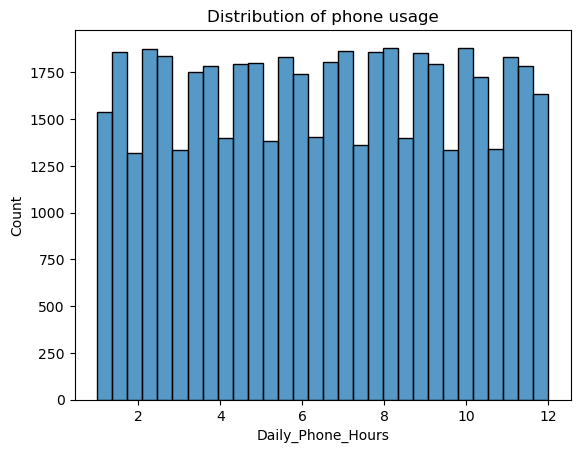

In [8]:
## Distribution of Phone Usage
sns.histplot(df_smartphone_usage['Daily_Phone_Hours'], bins = 30)
plt.title('Distribution of phone usage')
plt.show()

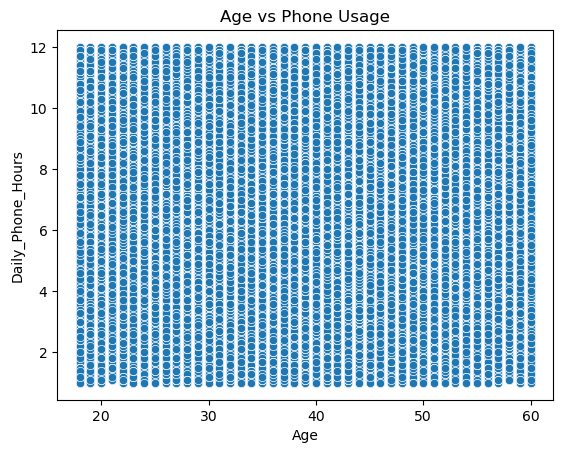

In [9]:
## Age vs phone usage:
sns.scatterplot(x='Age', y='Daily_Phone_Hours' , data = df_smartphone_usage)
plt.title('Age vs Phone Usage')
plt.show()

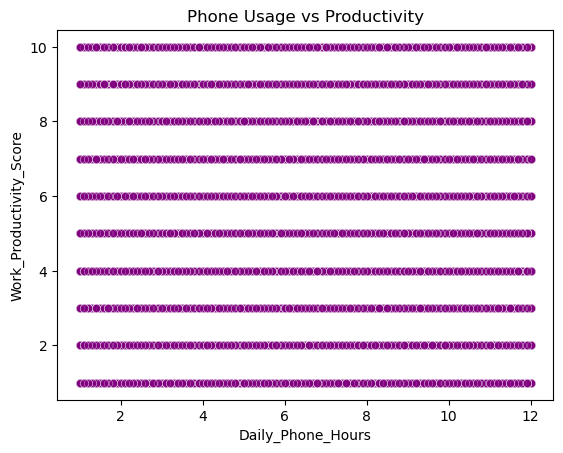

In [10]:
## Phone Usage vs Productivity
sns.scatterplot(x='Daily_Phone_Hours', y='Work_Productivity_Score', 
                data = df_smartphone_usage, color = 'purple', alpha=0.4)
plt.title('Phone Usage vs Productivity')
plt.show()

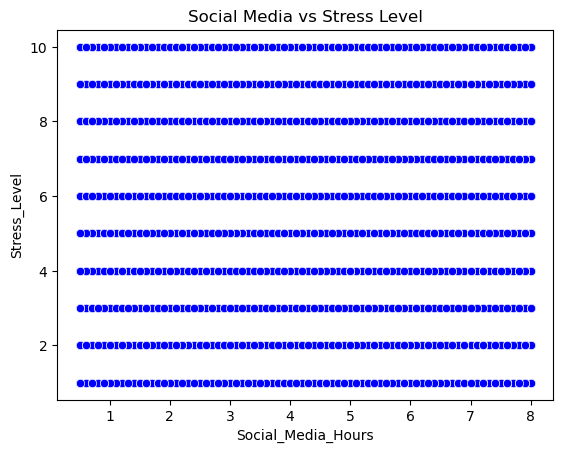

In [11]:
## Social Media vs Stress Level
sns.scatterplot(x='Social_Media_Hours', y='Stress_Level', data = df_smartphone_usage, color = 'blue')
plt.title('Social Media vs Stress Level')
plt.show()

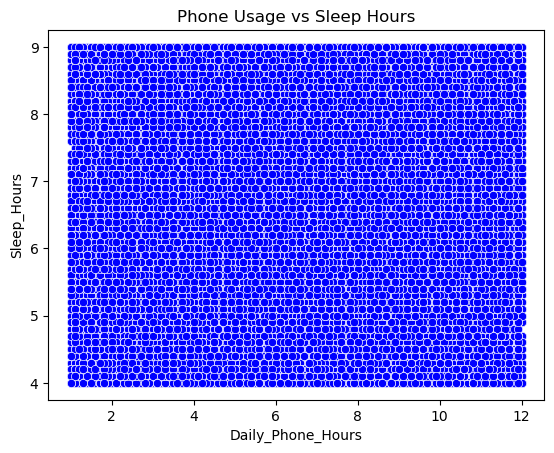

In [12]:
## Phone Usage vs Sleep Hours
sns.scatterplot(x='Daily_Phone_Hours', y='Sleep_Hours', data = df_smartphone_usage, color = 'blue')
plt.title('Phone Usage vs Sleep Hours')
plt.show()

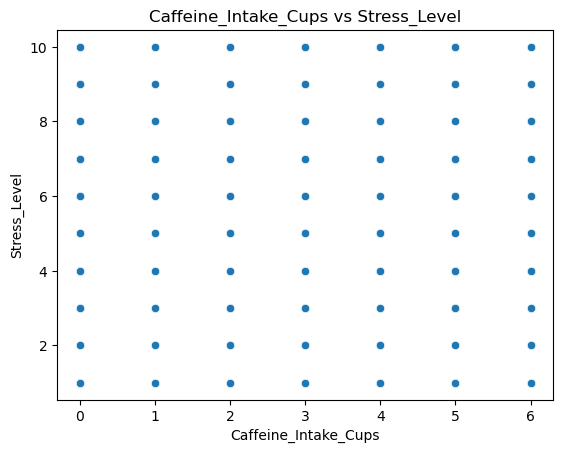

In [13]:
sns.scatterplot(x='Caffeine_Intake_Cups', y= 'Stress_Level', data = df_smartphone_usage)
plt.title('Caffeine_Intake_Cups vs Stress_Level')
plt.show()  

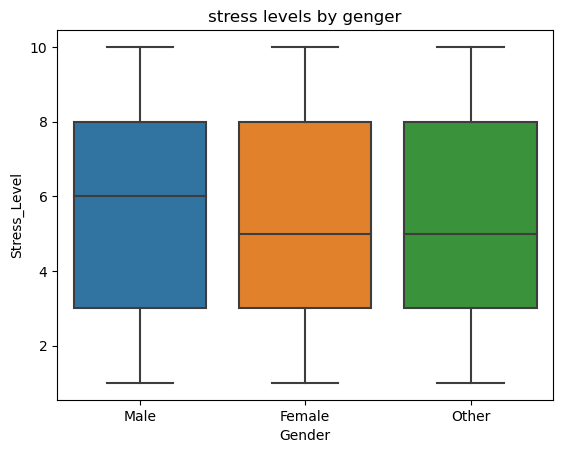

In [14]:
## stress levels by genger
sns.boxplot(x='Gender', y='Stress_Level', data=df_smartphone_usage)
plt.title('stress levels by genger')
plt.show()

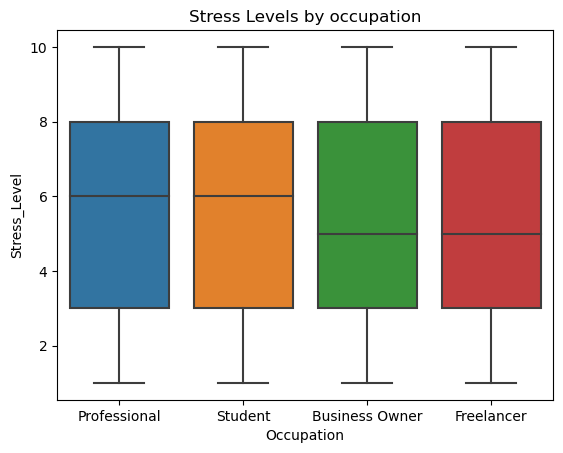

In [15]:
## Stress Levels by occupation
sns.boxplot(x='Occupation',y='Stress_Level', data=df_smartphone_usage)
plt.title('Stress Levels by occupation')
plt.show()

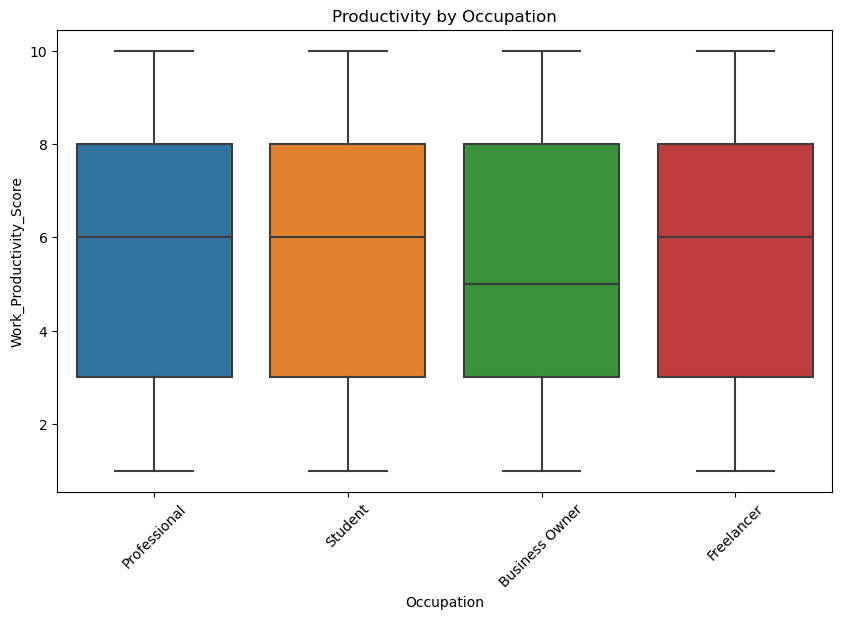

In [16]:
## Productivity by Occupation
plt.figure(figsize=(10,6))
sns.boxplot(x='Occupation', y='Work_Productivity_Score', data = df_smartphone_usage)
plt.xticks(rotation = 45)
plt.title('Productivity by Occupation')
plt.show()

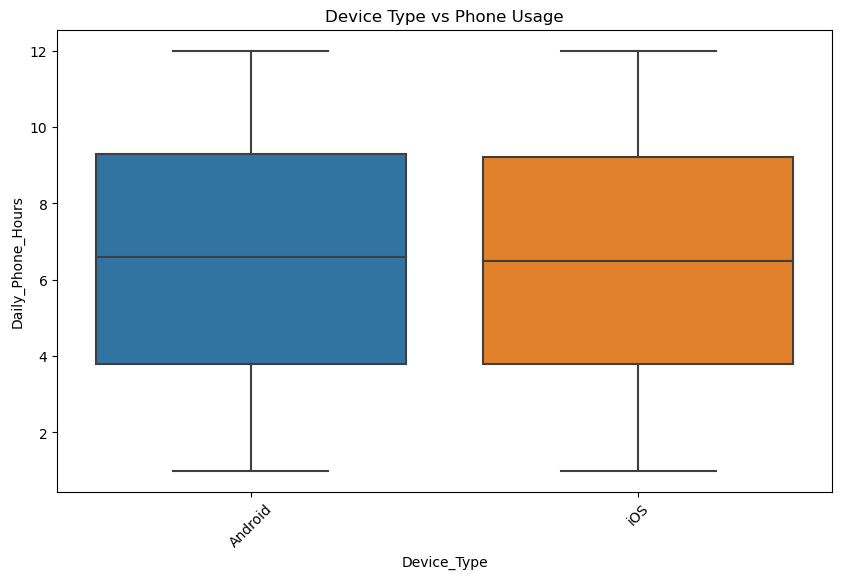

In [17]:
## Device Type vs Phone Usage
plt.figure(figsize=(10,6))
sns.boxplot(x='Device_Type',y='Daily_Phone_Hours',data=df_smartphone_usage)
plt.title('Device Type vs Phone Usage')
plt.xticks(rotation = 45)
plt.show()

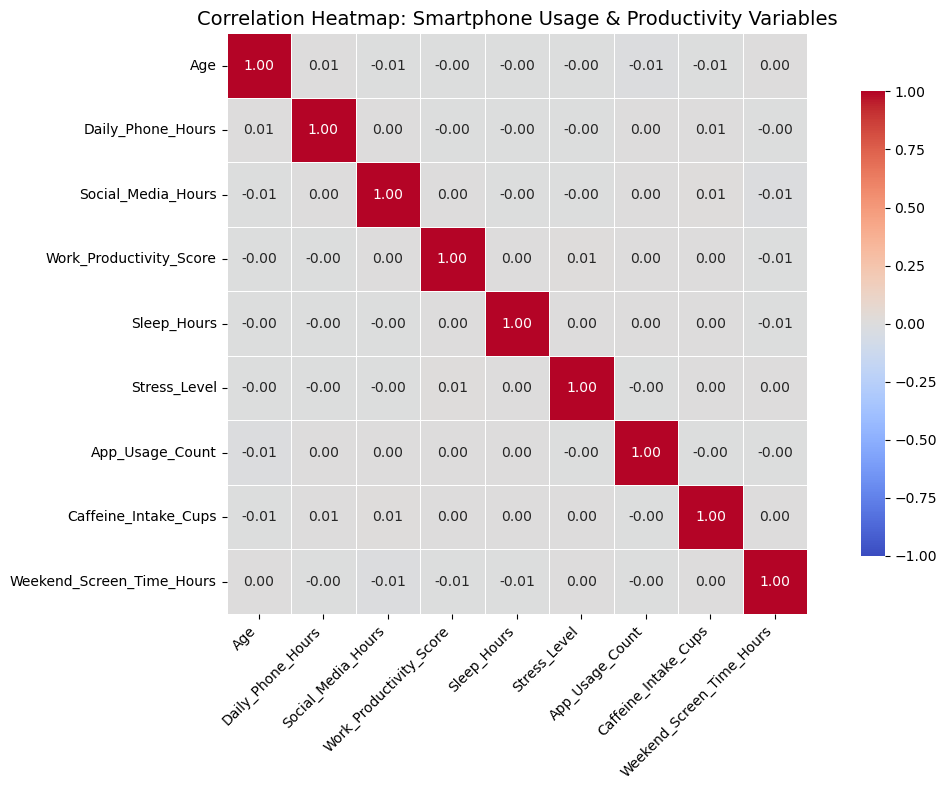

In [18]:
## Correlation Heatmap (LinkedIn-ready)

plt.figure(figsize=(12,8))

corr_matrix = df_smartphone_usage.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink":0.8}
)

plt.title("Correlation Heatmap: Smartphone Usage & Productivity Variables", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Feature Engineering:

In [19]:
df_smartphone_usage['Phone_Usage']=pd.cut(df_smartphone_usage['Daily_Phone_Hours'], 
                                          bins = [0,3,6,12], labels=['Low','Medium', 'High'])

In [20]:
df_smartphone_usage['Social_Media_Ratio']= (df_smartphone_usage['Social_Media_Hours']/
                                            df_smartphone_usage['Daily_Phone_Hours'])

In [21]:
df_smartphone_usage.head(5)

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,Phone_Usage,Social_Media_Ratio
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7,Low,5.153846
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1,Low,1.250000
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3,Medium,1.075472
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8,Medium,0.431034
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9,High,0.164557


In [22]:
df_smartphone_usage['Sleep_Deficit'] = 8 - df_smartphone_usage['Sleep_Hours']

In [23]:
df_smartphone_usage['Weekend_Extra_Usage']=(df_smartphone_usage['Weekend_Screen_Time_Hours']-
                                                                df_smartphone_usage['Daily_Phone_Hours'])

## Feature Selection

In [24]:
##Target variable is: Work_Productivity_Score
target = 'Work_Productivity_Score'

features = [
'Age',
'Daily_Phone_Hours',
'Social_Media_Hours',
'Sleep_Hours',
'Stress_Level',
'App_Usage_Count',
'Caffeine_Intake_Cups',
'Weekend_Screen_Time_Hours'
]

## Defining the X(input) and y(output) 
X = df_smartphone_usage[features]
y = df_smartphone_usage[target]

In [25]:
y

0        6
1        5
2        5
3        2
4        4
        ..
49995    5
49996    9
49997    4
49998    6
49999    3
Name: Work_Productivity_Score, Length: 50000, dtype: int64

## Modeling

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [27]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import r2_score, mean_squared_error
print('R2:', r2_score(y_test, y_pred))
print('RMSE:', mean_squared_error(y_test, y_pred, squared=False))

R2: -0.0005204195019694602
RMSE: 2.8826535060561533
